In [ ]:
!pip install imbalanced-learn
!pip install xgboost imbalanced-learn
!pip install shap
!pip install "numpy<2.0.0"

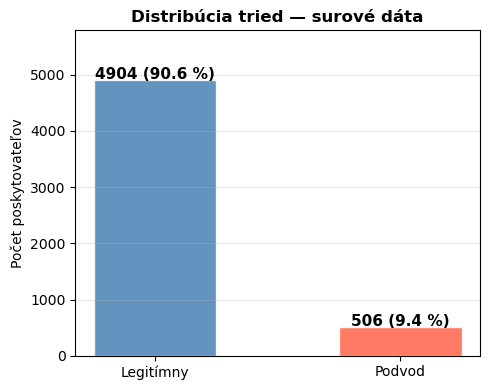

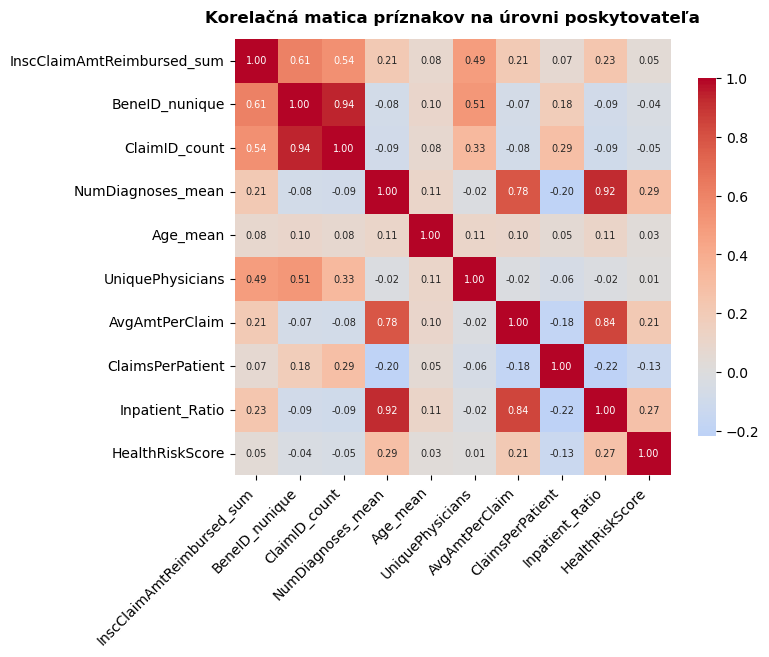

/tmp/ipykernel_65/3235467461.py:196: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


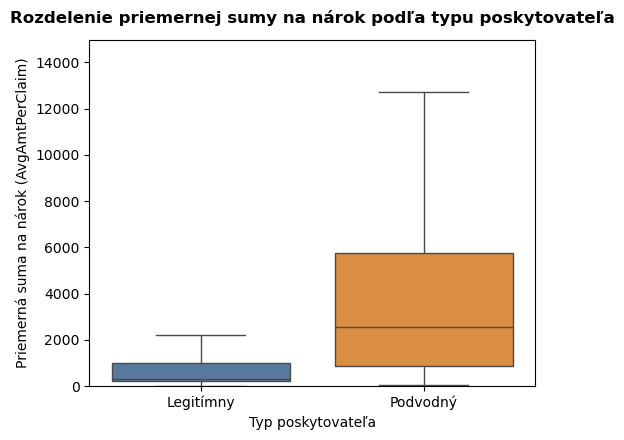


Rozdelenie dat
Povodna distribucia tried: Counter({0: 4904, 1: 506})
 Train:      3787 vzoriek (Fraud: 354) ~ 70%
 Validation: 541   vzoriek (Fraud: 51) ~ 10%
 Test:       1082  vzoriek (Fraud: 101) ~ 20%

SMOTE-ENN
 Pred: 3787 vzoriek — Counter({0: 3433, 1: 354})
 Po:   5311 vzoriek — Counter({1: 2684, 0: 2627})


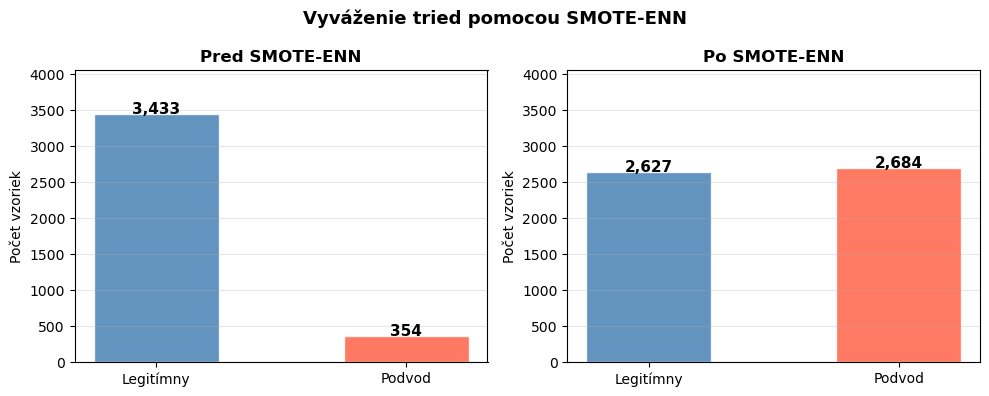


Grid Search — optimalizacia F1 (hybridny model)


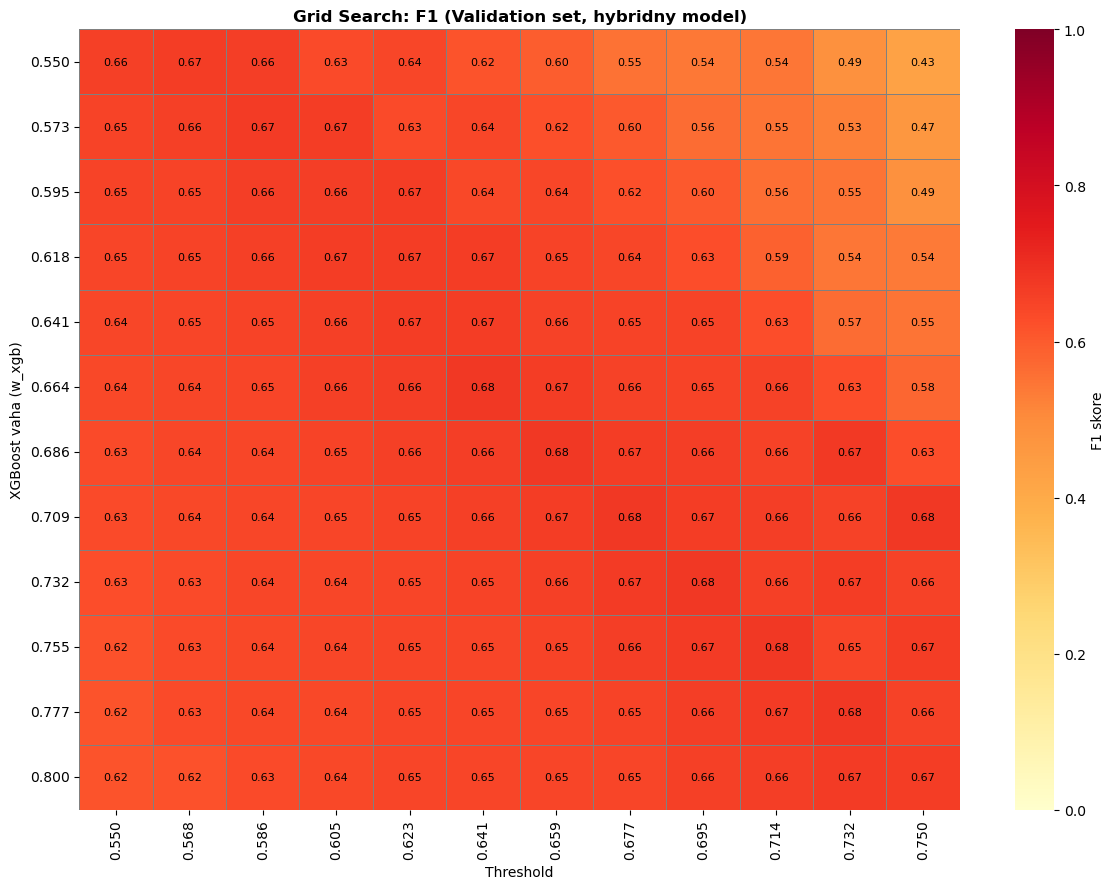


 OPTIMALNE PARAMETRE (hybrid):
   * XGBoost vaha: 0.709
   * Threshold:    0.750
   * F1 (val):     0.6783

--- KLASIFIKACNY REPORT (hybrid, best params) ---
              precision    recall  f1-score   support

   Legitimny       0.97      0.94      0.96       981
      Podvod       0.58      0.75      0.66       101

    accuracy                           0.93      1082
   macro avg       0.78      0.85      0.81      1082
weighted avg       0.94      0.93      0.93      1082

ROC AUC (hybrid): 0.9467
F1 (hybrid):      0.6580

--- KLASIFIKACNY REPORT (XGBoost, threshold 0.55) ---
              precision    recall  f1-score   support

   Legitimny       0.98      0.88      0.93       981
      Podvod       0.42      0.83      0.56       101

    accuracy                           0.88      1082
   macro avg       0.70      0.86      0.74      1082
weighted avg       0.93      0.88      0.89      1082

ROC AUC (XGBoost): 0.9468
F1 (XGBoost):      0.5581


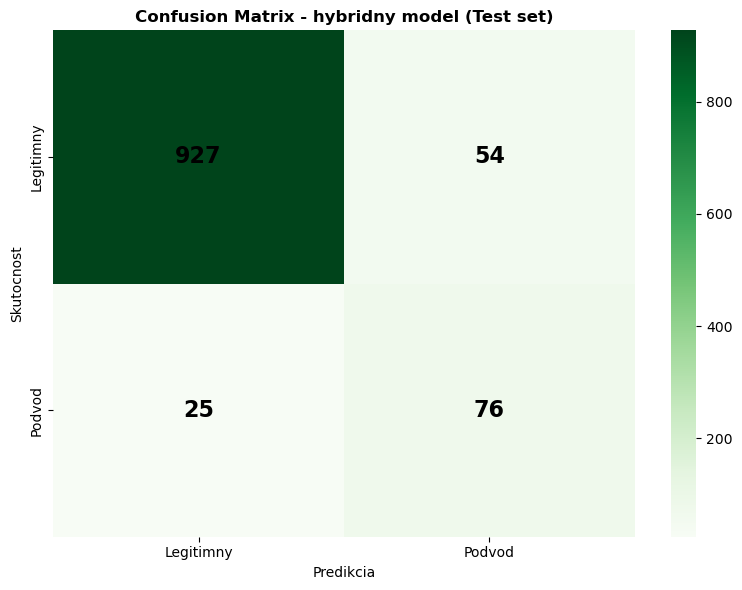

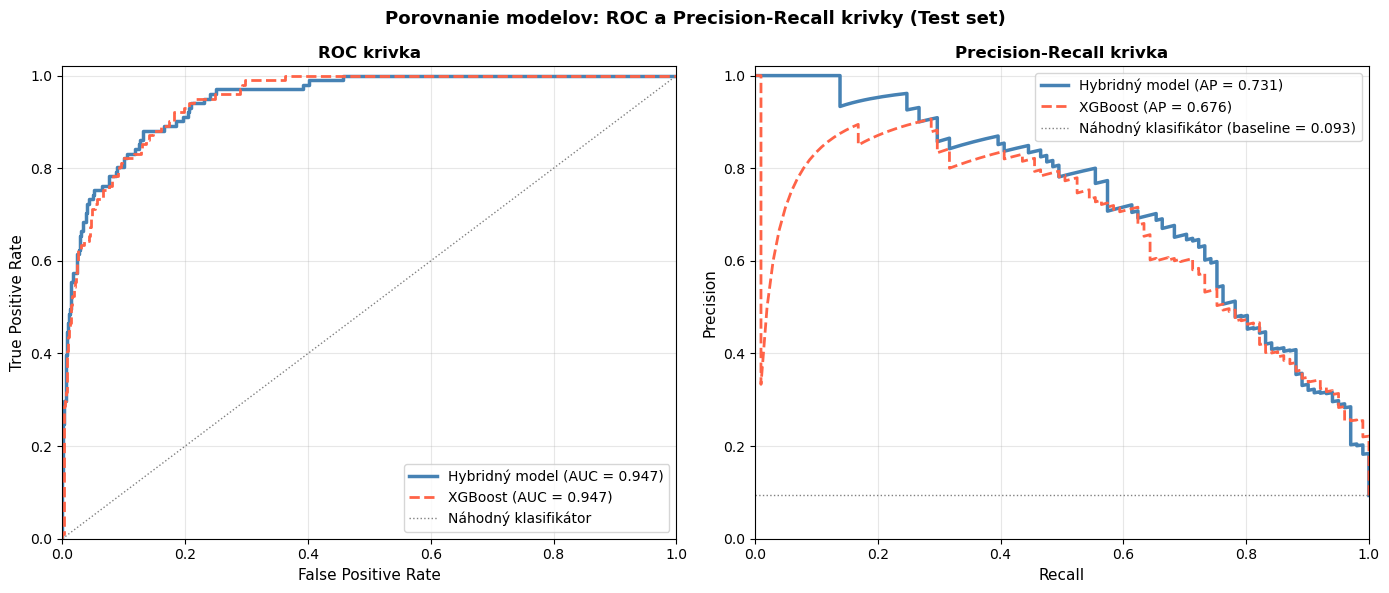

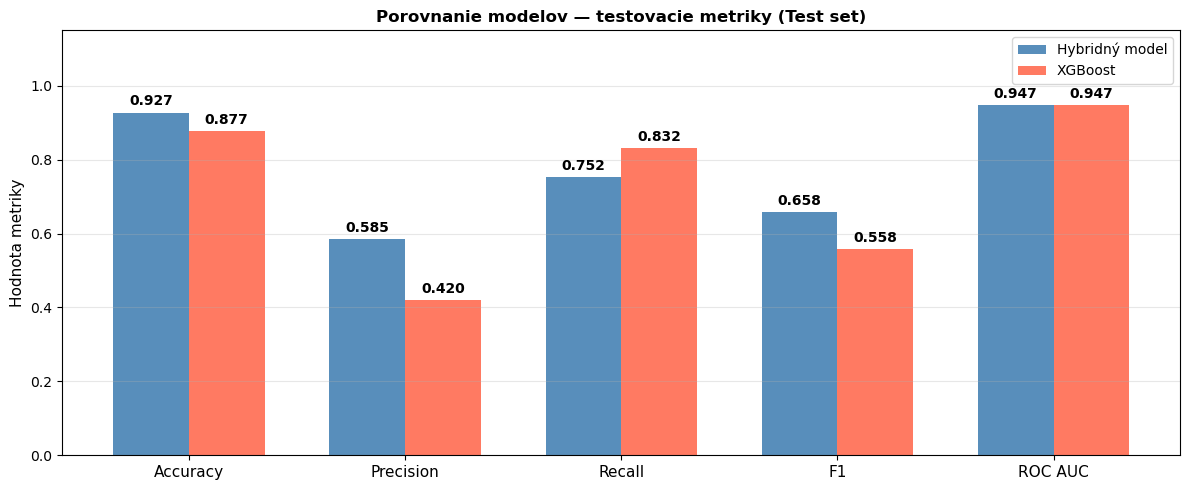

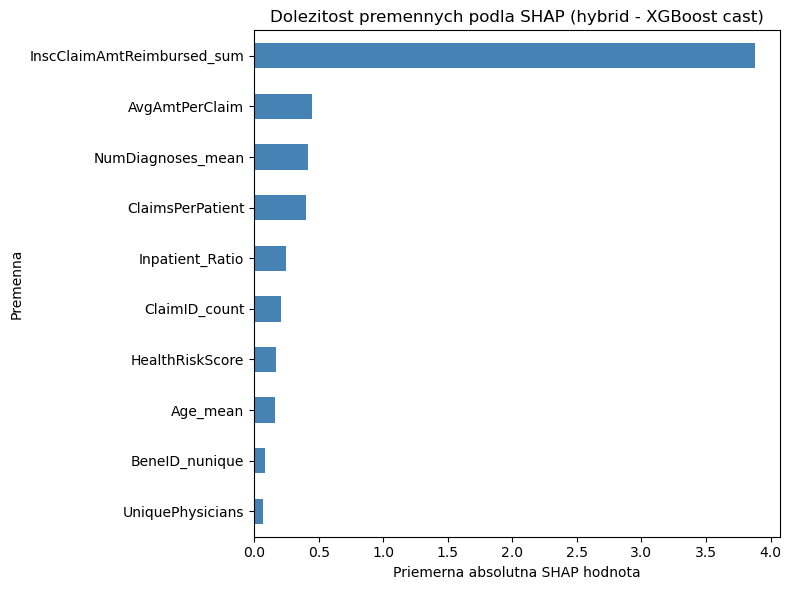

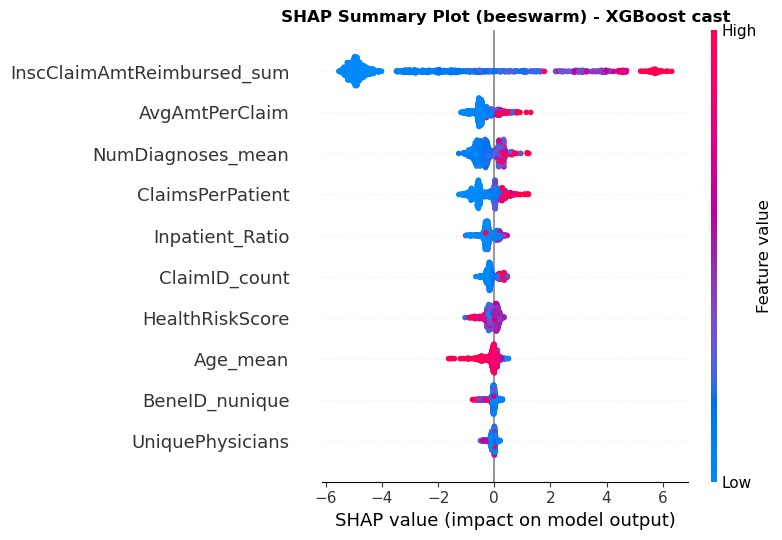

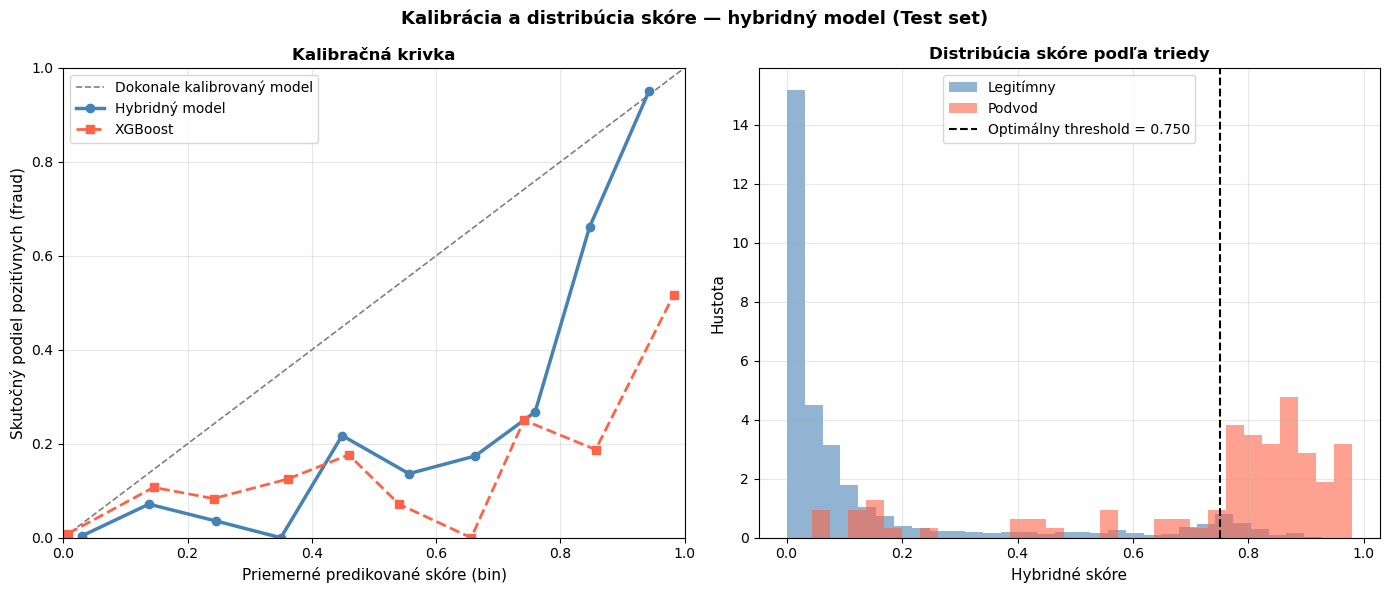


Celkova suma narokov fraud providerov (test): 71,978,270
Pocet providerov: 1082 (fraud: 101)

Podiel fraud expozicie zachyteny modelom:
   k_pct  n_audits  n_fraud_audit  share_fraud_audit  share_captured
0   0.05        54             45           0.833333        0.788240
1   0.10       108             71           0.657407        0.932982
2   0.15       162             79           0.487654        0.957468
3   0.20       216             88           0.407407        0.985329


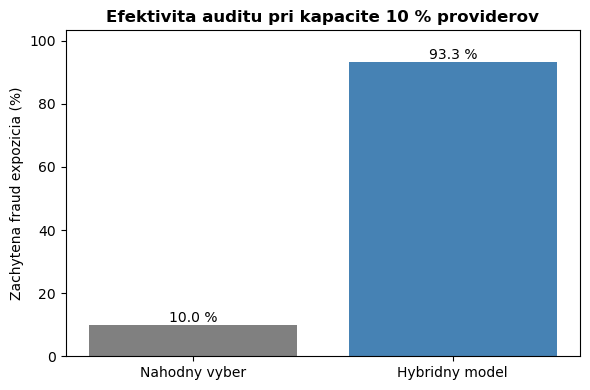

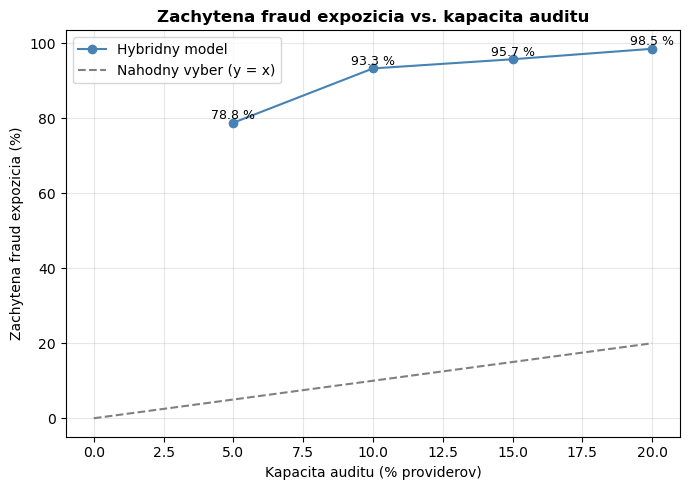

/tmp/ipykernel_65/3235467461.py:731: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_under_lorenz = np.trapz(y, x)


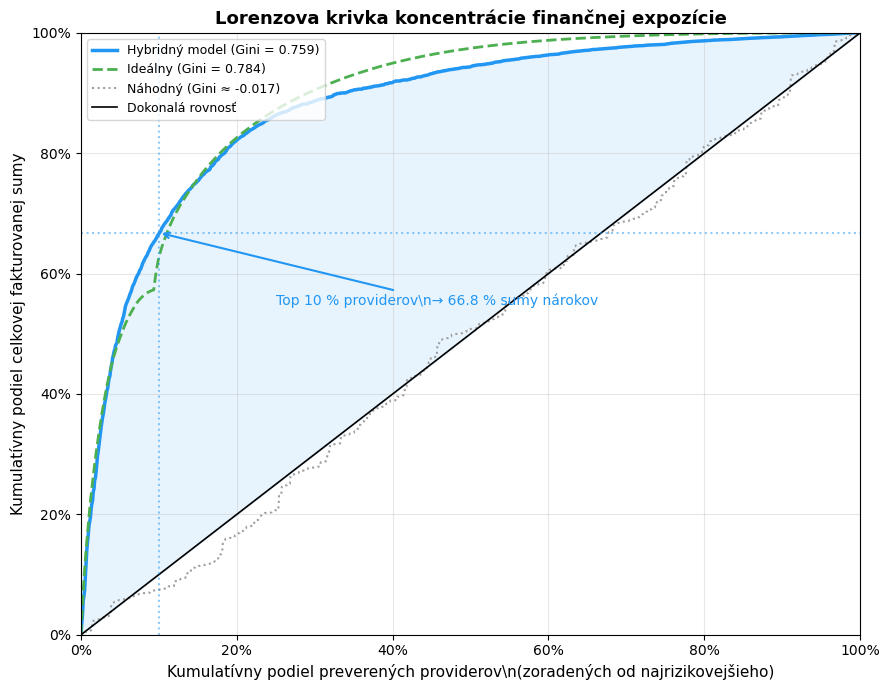

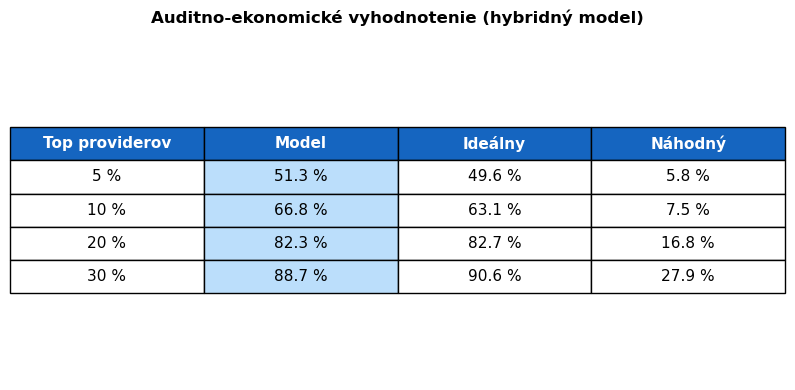

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from imblearn.combine import SMOTEENN
from collections import Counter
from xgboost import XGBClassifier
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, f1_score,
    roc_curve, precision_recall_curve, average_precision_score,
    precision_score, recall_score, accuracy_score
)
from sklearn.model_selection import train_test_split


# ------- 4.1. PRIPRAVA A AGREGACIA DAT -------
train_provider    = pd.read_csv('Train-1542865627584.csv')
train_beneficiary = pd.read_csv('Train_Beneficiarydata-1542865627584.csv')
train_inpatient   = pd.read_csv('Train_Inpatientdata-1542865627584.csv')

train_outpatient  = pd.read_csv('Train_Outpatientdata-1542865627584.csv', sep=None, engine='python')

# priznak inpatient / outpatient
train_inpatient['IsInpatient']  = 1
train_outpatient['IsInpatient'] = 0

# ClaimStartDt na datetime
train_inpatient['ClaimStartDt']  = pd.to_datetime(
    train_inpatient['ClaimStartDt'], format='%Y-%m-%d', errors='coerce'
)
train_outpatient['ClaimStartDt'] = pd.to_datetime(
    train_outpatient['ClaimStartDt'], dayfirst=True, errors='coerce'
)

# spojenie inpatient + outpatient
train_claims = pd.concat([train_inpatient, train_outpatient],
                         axis=0, sort=False)

# join s beneficiary a provider tabulkou
train_all = pd.merge(train_claims, train_beneficiary,
                     on='BeneID', how='left')
train_all = pd.merge(train_all, train_provider,
                     on='Provider', how='left')

# vek pacienta
train_all['DOB'] = pd.to_datetime(
    train_all['DOB'], format='%Y-%m-%d', errors='coerce'
)
train_all['ClaimStartDt'] = pd.to_datetime(
    train_all['ClaimStartDt'], format='%Y-%m-%d', errors='coerce'
)
train_all['Age'] = train_all['ClaimStartDt'].dt.year - train_all['DOB'].dt.year

# chronicke diagnozy: 1 = ano, 2 = nie -> 1 / 0
cols_to_fix = [col for col in train_all.columns if 'ChronicCond' in col]
for col in cols_to_fix:
    train_all[col] = train_all[col].replace({2: 0})

# label na 0/1
train_all['PotentialFraud'] = train_all['PotentialFraud'].map({'Yes': 1, 'No': 0})

# pocet diagnoz na claim
diag_cols = [c for c in train_all.columns if c.startswith('ClmDiagnosisCode_')]
train_all['NumDiagnoses'] = train_all[diag_cols].notna().sum(axis=1)

# agregacia na urovni providera (claim-level metriky)
claim_level_agg = train_all.groupby('Provider').agg({
    'PotentialFraud':            'max',
    'InscClaimAmtReimbursed':   ['sum', 'mean'],
    'BeneID':                    'nunique',
    'ClaimID':                   'count',
    'IsInpatient':               'sum',
    'NumDiagnoses':              'mean'
})
claim_level_agg.columns = [
    '_'.join(col).strip() if isinstance(col, tuple) else col
    for col in claim_level_agg.columns
]
claim_level_agg = claim_level_agg.rename(
    columns={'PotentialFraud_max': 'PotentialFraud'}
)

# pocet unikatnych lekarov na providera
phys_data = pd.concat([
    train_all[['Provider', 'AttendingPhysician']].rename(columns={'AttendingPhysician': 'Phys'}),
    train_all[['Provider', 'OperatingPhysician']].rename(columns={'OperatingPhysician': 'Phys'}),
    train_all[['Provider', 'OtherPhysician']].rename(columns={'OtherPhysician': 'Phys'}),
]).dropna()
phys_per_provider = phys_data.groupby('Provider')['Phys'] \
                             .nunique().rename('UniquePhysicians')

# bene-level agregacia
bene_level = train_all.drop_duplicates(['Provider', 'BeneID'])
bene_level_agg = bene_level.groupby('Provider').agg({
    'Age':                     'mean',
    'ChronicCond_Alzheimer':   'sum',
    'ChronicCond_Diabetes':    'sum'
})
bene_level_agg.columns = [
    'Age_mean',
    'ChronicCond_Alzheimer_sum',
    'ChronicCond_Diabetes_sum'
]

# finalna provider tabulka
train_provider_final = claim_level_agg.join(bene_level_agg).join(phys_per_provider)
train_provider_final['UniquePhysicians'] = \
    train_provider_final['UniquePhysicians'].fillna(0)



# ------- 4.2. FEATURE ENGINEERING -------

train_provider_final['AvgAmtPerClaim'] = (
    train_provider_final['InscClaimAmtReimbursed_sum'] /
    train_provider_final['ClaimID_count']
)
train_provider_final['ClaimsPerPatient'] = (
    train_provider_final['ClaimID_count'] /
    train_provider_final['BeneID_nunique']
)
train_provider_final['Inpatient_Ratio'] = (
    train_provider_final['IsInpatient_sum'] /
    train_provider_final['ClaimID_count']
)
train_provider_final['HealthRiskScore'] = (
    (train_provider_final['ChronicCond_Alzheimer_sum'] +
     train_provider_final['ChronicCond_Diabetes_sum']) /
    train_provider_final['BeneID_nunique']
)

train_provider_final.fillna(0, inplace=True)

redundant_cols = [
    'InscClaimAmtReimbursed_mean',
    'IsInpatient_sum',
    'ChronicCond_Alzheimer_sum',
    'ChronicCond_Diabetes_sum'
]

X_all = train_provider_final.drop(columns=['PotentialFraud'] + redundant_cols)
y_all = train_provider_final['PotentialFraud']
provider_ids = train_provider_final.index.to_series().rename('Provider')

#Distribucia tried
plt.figure(figsize=(5, 4))
counts = Counter(y_all)
bars = plt.bar(['Legitímny', 'Podvod'],
               [counts[0], counts[1]],
               color=['steelblue', 'tomato'],
               alpha=0.85, edgecolor='white', width=0.5)
for bar, v in zip(bars, [counts[0], counts[1]]):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 20,
             f'{v} ({v/sum(counts.values())*100:.1f} %)',
             ha='center', fontsize=11, fontweight='bold')
plt.title('Distribúcia tried — surové dáta', fontweight='bold')
plt.ylabel('Počet poskytovateľov')
plt.ylim(0, max(counts.values()) * 1.18)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('class_distribution_raw.png', dpi=300, bbox_inches='tight')
plt.show()

#1) Korelacna matica numerickych priznakov na urovni providera
plt.figure(figsize=(8, 7))
corr = X_all.corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    square=True,
    cbar_kws={'shrink': 0.7},
    annot=True,
    fmt='.2f',
    annot_kws={'fontsize': 7}
)

plt.title('Korelačná matica príznakov na úrovni poskytovateľa',
          fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('eda_correlation_matrix_clean.png', dpi=300, bbox_inches='tight')
plt.show()


# 2) Boxplot AvgAmtPerClaim vs. PotentialFraud
eda_df = X_all.copy()
eda_df['Typ'] = y_all.map({0: 'Legitímny', 1: 'Podvodný'})

plt.figure(figsize=(5.5, 4.5))
sns.boxplot(
    data=eda_df,
    x='Typ',
    y='AvgAmtPerClaim',
    palette=['#4e79a7', '#f28e2b'],
    showfliers=False  
)
plt.ylim(0, eda_df['AvgAmtPerClaim'].quantile(0.99))  
plt.xlabel('Typ poskytovateľa')
plt.ylabel('Priemerná suma na nárok (AvgAmtPerClaim)')
plt.title('Rozdelenie priemernej sumy na nárok podľa typu poskytovateľa',
          fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('eda_boxplot_avgamtperclaim_clean.png', dpi=300, bbox_inches='tight')
plt.show()



# ------- 4.3. ROZDELENIE DAT: TRAIN / VALIDATION / TEST (70 / 10 / 20) -------

print("\nRozdelenie dat")
print(f"Povodna distribucia tried: {Counter(y_all)}")

X_temp, X_test_raw, y_temp, y_test, prov_temp, prov_test = train_test_split(
    X_all, y_all, provider_ids,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

X_train_raw, X_val_raw, y_train, y_val, prov_train, prov_val = train_test_split(
    X_temp, y_temp, prov_temp,
    test_size=0.125,
    random_state=42,
    stratify=y_temp
)

X_train_raw = X_train_raw.copy()
X_val_raw   = X_val_raw.copy()
X_test_raw  = X_test_raw.copy()

X_train_raw['Provider'] = prov_train.values
X_val_raw['Provider']   = prov_val.values
X_test_raw['Provider']  = prov_test.values

X_train = X_train_raw.drop(columns=['Provider'])
X_val   = X_val_raw.drop(columns=['Provider'])
X_test  = X_test_raw.drop(columns=['Provider'])

print(f" Train:      {len(X_train)} vzoriek (Fraud: {int(y_train.sum())}) ~ {len(X_train)/len(X_all)*100:.0f}%")
print(f" Validation: {len(X_val)}   vzoriek (Fraud: {int(y_val.sum())}) ~ {len(X_val)/len(X_all)*100:.0f}%")
print(f" Test:       {len(X_test)}  vzoriek (Fraud: {int(y_test.sum())}) ~ {len(X_test)/len(X_all)*100:.0f}%")



# ------- 4.4. SMOTE-ENN -------

sme = SMOTEENN(random_state=42)
X_resampled, y_resampled = sme.fit_resample(X_train, y_train)

print("\nSMOTE-ENN")
print(f" Pred: {len(y_train)} vzoriek — {Counter(y_train)}")
print(f" Po:   {len(y_resampled)} vzoriek — {Counter(y_resampled)}")


# VIZUALIZACIA: SMOTEENN — vyvazenie tried pred a po
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['steelblue', 'tomato']
labels = ['Legitímny', 'Podvod']

counts_before = [Counter(y_train)[0], Counter(y_train)[1]]
counts_after  = [Counter(y_resampled)[0], Counter(y_resampled)[1]]

for ax, title, vals in zip(
    axes,
    ['Pred SMOTE-ENN', 'Po SMOTE-ENN'],
    [counts_before, counts_after]
):
    bars = ax.bar(labels, vals, color=colors, alpha=0.85, edgecolor='white', width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
                f'{v:,}', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel('Počet vzoriek')
    ax.set_ylim(0, max(counts_before) * 1.18)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Vyváženie tried pomocou SMOTE-ENN', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('smoteenn_balance.png', dpi=300, bbox_inches='tight')
plt.show()




# ------- 4.5. TRENOVANIE MODELOV (XGBoost + Isolation Forest) -------

xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_resampled, y_resampled)

fraud_ratio = y_train.mean()
iso_forest = IsolationForest(
    contamination=float(fraud_ratio),
    random_state=42,
    n_estimators=100
)
iso_forest.fit(X_train)

iso_scores_train = iso_forest.decision_function(X_train)
iso_score_min, iso_score_max = iso_scores_train.min(), iso_scores_train.max()

def normalize_iso_scores(scores, s_min, s_max):
    return np.clip(1 - (scores - s_min) / (s_max - s_min), 0, 1)


# ------- 4.6. GRID SEARCH - OPTIMALIZACIA PODLA F1 (VALIDATION SET) -------

print("\nGrid Search — optimalizacia F1 (hybridny model)")

y_prob_xgb_val = xgb_model.predict_proba(X_val)[:, 1]
iso_prob_val   = normalize_iso_scores(
    iso_forest.decision_function(X_val),
    iso_score_min, iso_score_max
)

w_xgb_range    = np.linspace(0.55, 0.80, 12)
threshold_range = np.linspace(0.55, 0.75, 12)
results = []

for w in w_xgb_range:
    for t in threshold_range:
        hybrid_scores_val = (w * y_prob_xgb_val) + ((1 - w) * iso_prob_val)
        preds_val         = (hybrid_scores_val >= t).astype(int)
        f1                = f1_score(y_val, preds_val, zero_division=0)
        results.append({'w_xgb': w, 'threshold': t, 'f1': f1})

res_df = pd.DataFrame(results)
best   = res_df.loc[res_df['f1'].idxmax()]

plt.figure(figsize=(12, 9))
pivot = res_df.pivot(index='w_xgb', columns='threshold', values='f1')
annot = pivot.map(lambda x: f'{x:.2f}')
ax = sns.heatmap(
    pivot, annot=annot, fmt='',
    cmap='YlOrRd', vmin=0, vmax=1,
    cbar_kws={'label': 'F1 skore'},
    linewidths=0.5, linecolor='gray',
    annot_kws={'fontsize': 8, 'color': 'black'}
)
ax.set_xticklabels([f'{float(t.get_text()):.3f}' for t in ax.get_xticklabels()])
ax.set_yticklabels([f'{float(t.get_text()):.3f}' for t in ax.get_yticklabels()])

plt.title('Grid Search: F1 (Validation set, hybridny model)', fontweight='bold')
plt.xlabel('Threshold')
plt.ylabel('XGBoost vaha (w_xgb)')
plt.tight_layout()
plt.savefig('hybrid_grid_search_f1.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n OPTIMALNE PARAMETRE (hybrid):")
print(f"   * XGBoost vaha: {best['w_xgb']:.3f}")
print(f"   * Threshold:    {best['threshold']:.3f}")
print(f"   * F1 (val):     {best['f1']:.4f}")


# ------- 4.7. FINALNE TESTOVANIE NA TEST SETE --------

y_prob_xgb_test = xgb_model.predict_proba(X_test)[:, 1]
iso_prob_test   = normalize_iso_scores(
    iso_forest.decision_function(X_test),
    iso_score_min, iso_score_max
)

final_scores = (best['w_xgb'] * y_prob_xgb_test) + \
               ((1 - best['w_xgb']) * iso_prob_test)
y_pred_final = (final_scores >= best['threshold']).astype(int)

print("\n--- KLASIFIKACNY REPORT (hybrid, best params) ---")
print(classification_report(y_test, y_pred_final,
                            target_names=['Legitimny', 'Podvod']))
auc_hybrid = roc_auc_score(y_test, final_scores)
f1_hybrid  = f1_score(y_test, y_pred_final, zero_division=0)
print(f"ROC AUC (hybrid): {auc_hybrid:.4f}")
print(f"F1 (hybrid):      {f1_hybrid:.4f}")

y_pred_xgb_test = (y_prob_xgb_test >= 0.55).astype(int)

print("\n--- KLASIFIKACNY REPORT (XGBoost, threshold 0.55) ---")
print(classification_report(y_test, y_pred_xgb_test,
                            target_names=['Legitimny', 'Podvod']))
auc_xgb = roc_auc_score(y_test, y_prob_xgb_test)
f1_xgb  = f1_score(y_test, y_pred_xgb_test, zero_division=0)
print(f"ROC AUC (XGBoost): {auc_xgb:.4f}")
print(f"F1 (XGBoost):      {f1_xgb:.4f}")


# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Legitimny', 'Podvod'],
            yticklabels=['Legitimny', 'Podvod'],
            annot_kws={'fontsize': 16, 'fontweight': 'bold', 'color': 'black'})
plt.title('Confusion Matrix - hybridny model (Test set)', fontweight='bold')
plt.ylabel('Skutocnost')
plt.xlabel('Predikcia')
plt.tight_layout()
plt.savefig('hybrid_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


# VIZUALIZACIA: ROC krivka + Precision-Recall krivka
fpr_h, tpr_h, _  = roc_curve(y_test, final_scores)
fpr_x, tpr_x, _  = roc_curve(y_test, y_prob_xgb_test)
prec_h, rec_h, _ = precision_recall_curve(y_test, final_scores)
prec_x, rec_x, _ = precision_recall_curve(y_test, y_prob_xgb_test)
ap_hybrid = average_precision_score(y_test, final_scores)
ap_xgb    = average_precision_score(y_test, y_prob_xgb_test)
baseline  = y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC
ax = axes[0]
ax.plot(fpr_h, tpr_h, color='steelblue', lw=2.5,
        label=f'Hybridný model (AUC = {auc_hybrid:.3f})')
ax.plot(fpr_x, tpr_x, color='tomato', lw=2, linestyle='--',
        label=f'XGBoost (AUC = {auc_xgb:.3f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle=':',
        label='Náhodný klasifikátor')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC krivka', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

# Precision-Recall
ax = axes[1]
ax.plot(rec_h, prec_h, color='steelblue', lw=2.5,
        label=f'Hybridný model (AP = {ap_hybrid:.3f})')
ax.plot(rec_x, prec_x, color='tomato', lw=2, linestyle='--',
        label=f'XGBoost (AP = {ap_xgb:.3f})')
ax.axhline(y=baseline, color='gray', lw=1, linestyle=':',
           label=f'Náhodný klasifikátor (baseline = {baseline:.3f})')
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall krivka', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

plt.suptitle('Porovnanie modelov: ROC a Precision-Recall krivky (Test set)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()


# VIZUALIZACIA: Porovnanie modelov — bar chart metrik
prec_hybrid = precision_score(y_test, y_pred_final, zero_division=0)
rec_hybrid  = recall_score(y_test, y_pred_final, zero_division=0)
acc_hybrid  = accuracy_score(y_test, y_pred_final)  
prec_xgb    = precision_score(y_test, y_pred_xgb_test, zero_division=0)
rec_xgb     = recall_score(y_test, y_pred_xgb_test, zero_division=0)
acc_xgb     = accuracy_score(y_test, y_pred_xgb_test) 

metric_names  = ['Accuracy','Precision', 'Recall', 'F1', 'ROC AUC']
hybrid_values = [acc_hybrid, prec_hybrid, rec_hybrid, f1_hybrid, auc_hybrid]
xgb_values    = [acc_xgb, prec_xgb,    rec_xgb,    f1_xgb,    auc_xgb]

x     = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width / 2, hybrid_values, width, label='Hybridný model', color='steelblue', alpha=0.9)
bars2 = ax.bar(x + width / 2, xgb_values, width, label='XGBoost', color='tomato', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.012,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.012,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Hodnota metriky', fontsize=11)
ax.set_title('Porovnanie modelov — testovacie metriky (Test set)',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


# ------- 4.8. SHAP ANALYZA - INTERPRETOVATELNOST -------

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# priemerna absolutna SHAP hodnota pre kazdu premennu
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False)

top_features = shap_importance.head(10).index.tolist()

plt.figure(figsize=(8, 6))
shap_importance.head(10)[::-1].plot(kind='barh', color='steelblue')
plt.xlabel('Priemerna absolutna SHAP hodnota')
plt.ylabel('Premenna')
plt.title('Dolezitost premennych podla SHAP (hybrid - XGBoost cast)')
plt.tight_layout()
plt.savefig('hybrid_shap_importance_bar.png', dpi=300, bbox_inches='tight')
plt.show()

# SHAP beeswarm plot - smer a velkost vplyvu kazdej premennej
shap.summary_plot(shap_values, X_test, plot_type='dot', show=False)
plt.title('SHAP Summary Plot (beeswarm) - XGBoost cast', fontweight='bold')
plt.tight_layout()
plt.savefig('hybrid_shap_summary_dot.png', dpi=300, bbox_inches='tight')
plt.show()

# ------- 4.8b. KALIBRACNA ANALYZA (CALIBRATION PLOT) -------
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Calibration curve ---
ax = axes[0]

fraction_pos_h, mean_pred_h = calibration_curve(
    y_test, final_scores, n_bins=10, strategy='uniform'
)
fraction_pos_x, mean_pred_x = calibration_curve(
    y_test, y_prob_xgb_test, n_bins=10, strategy='uniform'
)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray',
        label='Dokonale kalibrovaný model', linewidth=1.2)
ax.plot(mean_pred_h, fraction_pos_h,
        marker='o', color='steelblue', linewidth=2.5,
        label='Hybridný model')
ax.plot(mean_pred_x, fraction_pos_x,
        marker='s', color='tomato', linewidth=2, linestyle='--',
        label='XGBoost')

ax.set_xlabel('Priemerné predikované skóre (bin)', fontsize=11)
ax.set_ylabel('Skutočný podiel pozitívnych (fraud)', fontsize=11)
ax.set_title('Kalibračná krivka', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# --- Score distribution (histogram) vedla calibration curve ---
ax = axes[1]

ax.hist(final_scores[y_test == 0], bins=30, alpha=0.6,
        color='steelblue', label='Legitímny', density=True)
ax.hist(final_scores[y_test == 1], bins=30, alpha=0.6,
        color='tomato', label='Podvod', density=True)

ax.axvline(x=best['threshold'], color='black', linestyle='--', linewidth=1.5,
           label=f"Optimálny threshold = {best['threshold']:.3f}")

ax.set_xlabel('Hybridné skóre', fontsize=11)
ax.set_ylabel('Hustota', fontsize=11)
ax.set_title('Distribúcia skóre podľa triedy', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.suptitle('Kalibrácia a distribúcia skóre — hybridný model (Test set)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('hybrid_calibration_plot.png', dpi=300, bbox_inches='tight')
plt.show()


# ------- 4.9. PODIEL FRAUD EXPOZICIE ZACHYTENY V TOP K % PROVIDEROV --------

amounts_test = X_test_raw['InscClaimAmtReimbursed_sum'].values

# DataFrame s provider-level udajmi v test sete
test_df = X_test_raw.copy()
test_df['PotentialFraud'] = y_test.values
test_df['Score']          = final_scores
test_df['TotalPaid']      = amounts_test

# celkova fraud expozicia (suma narokov fraud providerov)
total_fraud_paid = test_df.loc[test_df['PotentialFraud'] == 1, 'TotalPaid'].sum()
n_prov_total     = len(test_df)
n_prov_fraud     = (test_df['PotentialFraud'] == 1).sum()

print(f"\nCelkova suma narokov fraud providerov (test): {total_fraud_paid:,.0f}")
print(f"Pocet providerov: {n_prov_total} (fraud: {n_prov_fraud})")

def fraud_exposure_for_k(test_df, k_pct):
    n = len(test_df)
    k = int(n * k_pct)
    sorted_df = test_df.sort_values('Score', ascending=False).reset_index(drop=True)
    top_k = sorted_df.iloc[:k]

    fraud_paid_topk = top_k.loc[top_k['PotentialFraud'] == 1, 'TotalPaid'].sum()
    share_captured  = fraud_paid_topk / total_fraud_paid if total_fraud_paid > 0 else 0

    n_audits      = len(top_k)
    n_fraud_audit = (top_k['PotentialFraud'] == 1).sum()
    share_fraud   = n_fraud_audit / n_audits if n_audits > 0 else 0

    return {
        'k_pct': k_pct,
        'n_audits': n_audits,
        'n_fraud_audit': n_fraud_audit,
        'share_fraud_audit': share_fraud,
        'fraud_paid_topk': fraud_paid_topk,
        'share_captured': share_captured
    }

ks = [0.05, 0.10, 0.15, 0.20]
exposure_rows = [fraud_exposure_for_k(test_df, k) for k in ks]
exposure_df   = pd.DataFrame(exposure_rows)

print("\nPodiel fraud expozicie zachyteny modelom:")
print(exposure_df[['k_pct', 'n_audits', 'n_fraud_audit',
                   'share_fraud_audit', 'share_captured']])




# ------- 4.10. VIZUALIZACIE EKONOMICKEJ EFEKTIVITY -------

k_target = 0.10
row_10   = exposure_df.loc[exposure_df['k_pct'] == k_target].iloc[0]

random_share = k_target
model_share  = row_10['share_captured']

plt.figure(figsize=(6, 4))
plt.bar(['Nahodny vyber', 'Hybridny model'],
        [random_share * 100, model_share * 100],
        color=['gray', 'steelblue'])
plt.ylabel('Zachytena fraud expozicia (%)')
plt.title('Efektivita auditu pri kapacite 10 % providerov', fontweight='bold')
for i, v in enumerate([random_share * 100, model_share * 100]):
    plt.text(i, v + 1, f'{v:.1f} %', ha='center', fontsize=10)
plt.ylim(0, max(model_share * 100, random_share * 100) + 10)
plt.tight_layout()
plt.savefig('hybrid_fraud_exposure_random_vs_model.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(exposure_df['k_pct'] * 100,
         exposure_df['share_captured'] * 100,
         marker='o', color='steelblue', label='Hybridny model')
plt.plot([0, 20], [0, 20], linestyle='--', color='gray',
         label='Nahodny vyber (y = x)')
plt.xlabel('Kapacita auditu (% providerov)')
plt.ylabel('Zachytena fraud expozicia (%)')
plt.title('Zachytena fraud expozicia vs. kapacita auditu', fontweight='bold')
plt.legend()
for _, r in exposure_df.iterrows():
    plt.text(r['k_pct'] * 100, r['share_captured'] * 100 + 1,
             f'{r["share_captured"] * 100:.1f} %', ha='center', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('hybrid_fraud_exposure_curve.png', dpi=300, bbox_inches='tight')
plt.show()


# ------- 4.11. VYSVETLENIE TOP 20 NAJRIZIKOVEJSICH PROVIDEROV -------

def risk_label(score):
    if score >= 0.7:
        return 'Vysoke'
    elif score >= 0.4:
        return 'Stredne'
    else:
        return 'Nizke'

test_df_indexed = test_df.copy()
test_df_indexed['_shap_idx'] = np.arange(len(test_df_indexed))

ranking_df = test_df_indexed.sort_values('Score', ascending=False).reset_index(drop=True)
ranking_df['RiskBand'] = ranking_df['Score'].apply(risk_label)

X_test_explain = X_test.copy().reset_index(drop=True)
shap_df        = pd.DataFrame(shap_values, columns=X_test.columns)

def main_suspicious_factor(shap_idx):
    shap_row    = shap_df.loc[shap_idx]
    top_feature = shap_row.abs().idxmax()
    top_value   = X_test_explain.loc[shap_idx, top_feature]
    return f"{top_feature} ({top_value:.2f})"

ranking_df['MainSuspiciousFactor'] = ranking_df['_shap_idx'].apply(main_suspicious_factor)

top20_simple = ranking_df.head(20)[[
    'Provider',
    'Score',
    'RiskBand',
    'PotentialFraud',
    'TotalPaid',
    'MainSuspiciousFactor'
]].copy()

top20_simple.to_excel("top20_provider_summary.xlsx", index=False)


# ------- 4.13. LORENZOVA KRIVKA & GINIHO KOEFICIENT (koncentrácia finančnej expozície – hybridný model) -------

def lorenz_curve(scores, amounts):
    order      = np.argsort(scores)[::-1]
    amt_sorted = amounts[order]
    n          = len(amounts)
    x_lorenz   = np.linspace(0, 1, n + 1)
    y_lorenz   = np.concatenate(
        [[0], np.cumsum(amt_sorted) / amt_sorted.sum()]
    )
    return x_lorenz, y_lorenz

def gini_from_lorenz(x, y):
    area_under_lorenz = np.trapz(y, x)
    return 2 * (area_under_lorenz - 0.5)

x_model,  y_model  = lorenz_curve(final_scores, amounts_test)
random_scores      = np.random.default_rng(42).uniform(0, 1, len(final_scores))
x_random, y_random = lorenz_curve(random_scores, amounts_test)
ideal_key          = y_test.values * 1e15 + amounts_test
x_ideal,  y_ideal  = lorenz_curve(ideal_key, amounts_test)

gini_model  = gini_from_lorenz(x_model,  y_model)
gini_random = gini_from_lorenz(x_random, y_random)
gini_ideal  = gini_from_lorenz(x_ideal,  y_ideal)

def pct_coverage(x_lorenz, y_lorenz, top_pct):
    idx = np.searchsorted(x_lorenz, top_pct)
    idx = min(idx, len(y_lorenz) - 1)
    return y_lorenz[idx] * 100

coverage_rows = []
for pct in [0.05, 0.10, 0.20, 0.30]:
    coverage_rows.append({
        'Top providerov (%)': f'{pct*100:.0f} %',
        'Model (% sumy)':     f'{pct_coverage(x_model,  y_model,  pct):.1f} %',
        'Ideál (% sumy)':     f'{pct_coverage(x_ideal,  y_ideal,  pct):.1f} %',
        'Náhodný (% sumy)':   f'{pct_coverage(x_random, y_random, pct):.1f} %',
    })

coverage_df = pd.DataFrame(coverage_rows)


# Lorenzova krivka
fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(x_model, y_model, color='#2196F3', linewidth=2.5,
        label=f'Hybridný model (Gini = {gini_model:.3f})')
ax.plot(x_ideal, y_ideal, color='#4CAF50', linewidth=2,
        linestyle='--', label=f'Ideálny (Gini = {gini_ideal:.3f})')
ax.plot(x_random, y_random, color='#9E9E9E', linewidth=1.5,
        linestyle=':', label=f'Náhodný (Gini ≈ {gini_random:.3f})')
ax.plot([0, 1], [0, 1], color='black', linewidth=1.2,
        linestyle='-', label='Dokonalá rovnosť')

top10_pct = pct_coverage(x_model, y_model, 0.10)
ax.annotate(
    f'Top 10 % providerov\\n→ {top10_pct:.1f} % sumy nárokov',
    xy=(0.10, top10_pct / 100),
    xytext=(0.25, top10_pct / 100 - 0.12),
    fontsize=10, color='#2196F3',
    arrowprops=dict(arrowstyle='->', color='#2196F3', lw=1.5)
)
ax.axvline(x=0.10, color='#2196F3', linestyle=':', alpha=0.5)
ax.axhline(y=top10_pct / 100, color='#2196F3', linestyle=':', alpha=0.5)
ax.fill_between(x_model, y_model, x_model, alpha=0.10, color='#2196F3')

ax.set_xlabel('Kumulatívny podiel preverených providerov\\n(zoradených od najrizikovejšieho)',
              fontsize=11)
ax.set_ylabel('Kumulatívny podiel celkovej fakturovanej sumy', fontsize=11)
ax.set_title('Lorenzova krivka koncentrácie finančnej expozície',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))

plt.tight_layout()
plt.savefig('hybrid_lorenz_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# auditno-ekonomicke vyhodnotenie
fig, ax2 = plt.subplots(figsize=(8, 4))
ax2.axis('off')

table_data = [['Top providerov', 'Model', 'Ideálny', 'Náhodný']]
for pct in [0.05, 0.10, 0.20, 0.30]:
    table_data.append([
        f'{pct*100:.0f} %',
        f'{pct_coverage(x_model,  y_model,  pct):.1f} %',
        f'{pct_coverage(x_ideal,  y_ideal,  pct):.1f} %',
        f'{pct_coverage(x_random, y_random, pct):.1f} %',
    ])

tbl = ax2.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 1.8)

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1565C0')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == 1:
        cell.set_facecolor('#BBDEFB')

ax2.set_title('Auditno‑ekonomické vyhodnotenie (hybridný model)',
              fontsize=12, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('hybrid_audit_table.png', dpi=300, bbox_inches='tight')
plt.show()